In [57]:
import pandas as pd
DATA_DIR= "../data"
import os
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
import healpy as hp
import fitsio
import matplotlib.pyplot as plt

In [2]:
a = pd.read_csv(os.path.join(DATA_DIR,"delve_dr3qr_combo_v10.csv"))

In [3]:
a.columns.values

array(['pfw_attempt_id', 'expnum', 'unitname', 'reqnum', 'attnum', 'path',
       'ra', 'dec', 'glon', 'glat', 'band', 'exptime', 'nite', 't_eff',
       'psf_fwhm', 'n_objects', 'astrom_chi2', 'astrom_sigma',
       'astrom_ndets', 'flag', 'propid', 'tag', 'zps'], dtype=object)

In [88]:
a.iloc[1]

pfw_attempt_id                                              2282746
expnum                                                       226651
unitname                                                  D00226651
reqnum                                                           -1
attnum                                                           -1
path              /data/delve01.b/data/chinyi/dr3qr_skims/cat/de...
ra                                                       308.664733
dec                                                      -51.952498
glon                                                      346.73535
glat                                                     -36.716948
band                                                              z
exptime                                                        90.0
nite                                                       20130815
t_eff                                                      0.841791
psf_fwhm                                        

## Pilot run

In [12]:
ELAISS_CENTER = SkyCoord(ra=9.45*u.deg,dec=-44.02*u.deg,unit='deg')
DECamCoords = SkyCoord(ra=a['ra']*u.deg,dec=a['dec']*u.deg,unit='deg')
max_dist = 3*u.deg
sep = ELAISS_CENTER.separation(DECamCoords)
is_within = sep <= max_dist

In [14]:
a[is_within]

,pfw_attempt_id,expnum,unitname,reqnum,attnum,path,ra,dec,glon,glat,...,t_eff,psf_fwhm,n_objects,astrom_chi2,astrom_sigma,astrom_ndets,flag,propid,tag,zps
999,2281857,232441,D00232441,-1,-1,/data/delve01.b/data/chinyi/dr3qr_skims/cat/de...,13.364908,-45.037888,301.770804,-72.085803,...,1.339070,0.766,162223,29.816000,0.030468,4355,0,2012B-0001,Y6A1_COADD_INPUT,True
1000,2282848,232442,D00232442,-1,-1,/data/delve01.b/data/chinyi/dr3qr_skims/cat/de...,8.844121,-45.037415,312.050190,-71.805396,...,1.154071,0.816,152672,29.618999,0.030580,4410,10000,2012B-0001,Y6A1_COADD_INPUT,True
1368,2239252,233600,D00233600,-1,-1,/data/delve01.b/data/chinyi/dr3qr_skims/cat/de...,5.925254,-44.851526,318.520570,-71.427750,...,0.896253,1.067,126529,13.426000,0.033767,2460,0,2012B-0001,Y6A1_COADD_INPUT,True
2084,2283066,239723,D00239723,-1,-1,/data/delve01.b/data/chinyi/dr3qr_skims/cat/de...,6.691292,-44.023804,317.726767,-72.388762,...,0.512208,0.944,92973,14.262000,0.031394,2019,0,2012B-0001,Y6A1_COADD_INPUT,True
2085,2282091,239724,D00239724,-1,-1,/data/delve01.b/data/chinyi/dr3qr_skims/cat/de...,6.691379,-44.022582,317.727848,-72.389941,...,0.383580,0.890,105517,20.761000,0.030030,2979,10000,2012B-0001,Y6A1_COADD_INPUT,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61734,2436648,797856,D00797856,-1,-1,/data/delve01.b/data/chinyi/dr3qr_skims/cat/de...,11.131829,-41.605054,308.081683,-75.454024,...,1.484647,0.809,177443,30.992001,0.050762,887,0,2012B-0001,Y6A1_COADD_INPUT,True
61735,2436649,797857,D00797857,-1,-1,/data/delve01.b/data/chinyi/dr3qr_skims/cat/de...,11.075746,-43.634026,307.463220,-73.431395,...,1.189931,0.824,181269,42.966000,0.045400,3423,0,2012B-0001,Y6A1_COADD_INPUT,True
61736,2437715,797858,D00797858,-1,-1,/data/delve01.b/data/chinyi/dr3qr_skims/cat/de...,11.075717,-43.633888,307.463340,-73.431530,...,1.475125,0.813,166022,29.834999,0.050293,970,0,2012B-0001,Y6A1_COADD_INPUT,True
61737,2437463,797859,D00797859,-1,-1,/data/delve01.b/data/chinyi/dr3qr_skims/cat/de...,13.305871,-44.648388,301.877234,-72.476205,...,1.406304,0.768,192593,45.388000,0.046980,3325,0,2012B-0001,Y6A1_COADD_INPUT,True


In [16]:
exclude = fitsio.read(os.path.join(DATA_DIR,"delve_exclude_20260101.fits"))

In [23]:
exclude

array([( 145507, 14, 'Ghost/Scatter', 'kadrlica'),
       ( 145507, 13, 'Ghost/Scatter', 'kadrlica'),
       ( 145507,  9, 'Ghost/Scatter', 'kadrlica'), ...,
       (1381260, 48, 'Ghost/Scatter', 'kadrlica'),
       (1381260, 47, 'Ghost/Scatter', 'kadrlica'),
       (1381260, 53, 'Ghost/Scatter', 'kadrlica')],
      shape=(95343,), dtype=[('EXPNUM', '>i4'), ('CCDNUM', '>i2'), ('REASON', '<U30'), ('ANALYST', '<U30')])

In [28]:
dropVis = []
for k in a[is_within]['expnum']:
    if k in exclude['EXPNUM'] and len(exclude[exclude['EXPNUM']==k]['CCDNUM'])>30:
        # excl_mask = 
        # print(k,,np.unique(exclude[excl_mask]['REASON']))
        dropVis.append(k)

In [29]:
dropVis

[247159, 670009]

In [31]:
with open(os.path.join(DATA_DIR,"pilot_elais_s1.txt"),"w") as f:
    for k in a[is_within]['expnum']:
        if k not in dropVis:
            f.write(str(k))
            f.write("\n")

In [ ]:
with open(os.path.join(DATA_DIR,"pilot_elais_s1.txt"),"w") as f:
    for enum in zip(a[is_within]['expnum'],a[is_within]['md:
        if enum not in dropVis:
            f.write(str(md5))
            f.write("\n")

In [55]:
a.columns.values

array(['pfw_attempt_id', 'expnum', 'unitname', 'reqnum', 'attnum', 'path',
       'ra', 'dec', 'glon', 'glat', 'band', 'exptime', 'nite', 't_eff',
       'psf_fwhm', 'n_objects', 'astrom_chi2', 'astrom_sigma',
       'astrom_ndets', 'flag', 'propid', 'tag', 'zps'], dtype=object)

### Quick diagnostic on per-pointing

In [50]:
covDict = {}
nside=1024
for b in list("griz"):
    covDict[b] = np.zeros(hp.nside2npix(nside))
for idx,row in a[is_within].iterrows():
    if row['expnum'] not in dropVis:
        covDict[row['band']][hp.query_disc(nside,hp.ang2vec(row['ra'],row['dec'],lonlat=True),0.97*np.pi/180)]+=1

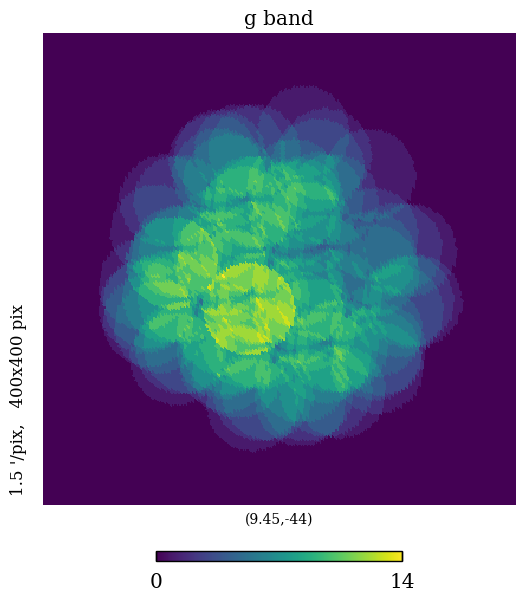

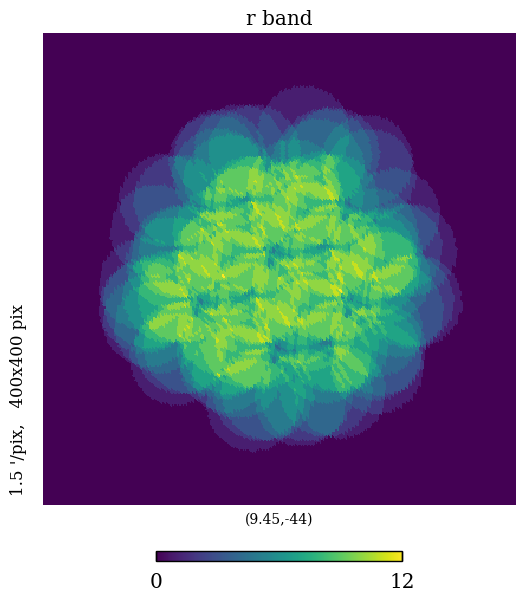

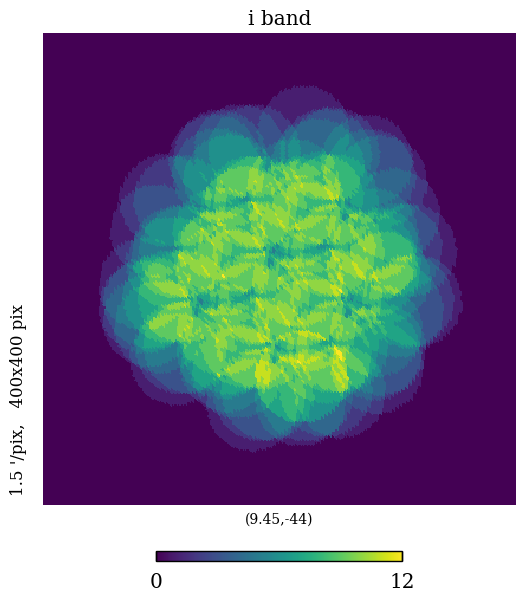

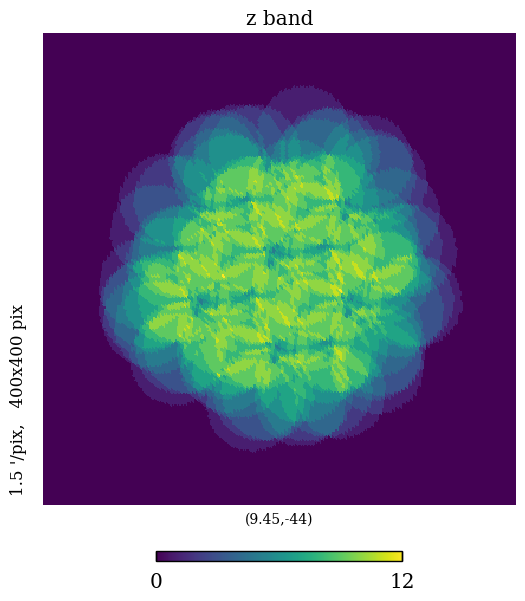

In [51]:
for band,coverage in covDict.items():
    hp.gnomview(coverage,rot=(9.45,-44),xsize=400,title=f"{band} band")

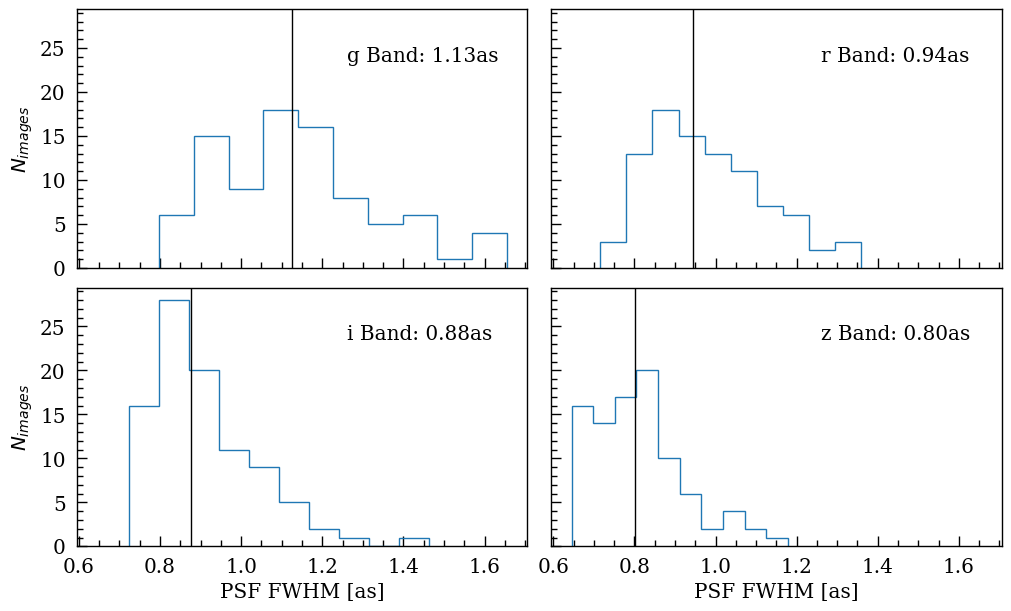

In [87]:
fig,axs = plt.subplots(2,2,figsize=(10,6),layout='constrained',
                      sharex=True,sharey=True)
for b,ax in zip(list("griz"),axs.flatten()):
    msk = np.logical_and(is_within,a['band']==b)
    ax.hist(a['psf_fwhm'][msk],histtype='step')
    ax.axvline(np.median(a['psf_fwhm'][msk]))
    ax.text(0.6,0.8,f"{b} Band: {np.median(a['psf_fwhm'][msk]):.2f}as",transform=ax.transAxes,fontsize='x-large')
for ax in axs[1,:]:
    ax.set_xlabel("PSF FWHM [as]")
for ax in axs[:,0]:
    ax.set_ylabel("$N_{images}$")